In [2]:
import pandas as pd

# Cargar el archivo
df = pd.read_csv('datos_tratados.csv')

# Ver primeras filas
df.head()

,id_cliente,abandono_cliente,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefonico,lineas_multiples,tipo_internet,...,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,cargo_mensual,cargo_total,cargo_diario,internet_streaming,cliente_temprano,riesgo_temprano
0,0002-ORFBO,0,Female,0.0,1,1,9.0,1,0,DSL,...,0,One year,1,Mailed check,65.6,593.30,2.186667,DSL_01,1,1
1,0003-MKNFE,0,Male,0.0,0,0,9.0,1,1,DSL,...,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667,DSL_10,1,2
2,0004-TLHLJ,1,Male,0.0,0,0,4.0,1,0,Fiber optic,...,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,Fiber optic_00,1,4
3,0011-IGKFF,1,Male,1.0,1,0,13.0,1,0,Fiber optic,...,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,Fiber optic_11,0,2
4,0013-EXCHZ,1,Female,1.0,1,0,3.0,1,0,Fiber optic,...,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,Fiber optic_01,1,3


In [3]:
# Información general
df.info()

# Estadísticos básicos
df.describe()

# Ver distribución de la variable objetivo
df['abandono_cliente'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6830 entries, 0 to 6829
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              6830 non-null   object 
 1   abandono_cliente        6830 non-null   int64  
 2   genero                  6830 non-null   object 
 3   adulto_mayor            6830 non-null   float64
 4   tiene_pareja            6830 non-null   int64  
 5   tiene_dependientes      6830 non-null   int64  
 6   antiguedad_meses        6830 non-null   float64
 7   servicio_telefonico     6830 non-null   int64  
 8   lineas_multiples        6830 non-null   int64  
 9   tipo_internet           6830 non-null   object 
 10  seguridad_en_linea      6830 non-null   int64  
 11  respaldo_en_linea       6830 non-null   int64  
 12  proteccion_dispositivo  6830 non-null   int64  
 13  soporte_tecnico         6830 non-null   int64  
 14  streaming_tv            6830 non-null   

,proportion
abandono_cliente,
0,0.733382
1,0.266618


In [4]:
# Ver lista completa de columnas
df.columns.tolist()

['id_cliente',
 'abandono_cliente',
 'genero',
 'adulto_mayor',
 'tiene_pareja',
 'tiene_dependientes',
 'antiguedad_meses',
 'servicio_telefonico',
 'lineas_multiples',
 'tipo_internet',
 'seguridad_en_linea',
 'respaldo_en_linea',
 'proteccion_dispositivo',
 'soporte_tecnico',
 'streaming_tv',
 'streaming_peliculas',
 'tipo_contrato',
 'facturacion_digital',
 'metodo_pago',
 'cargo_mensual',
 'cargo_total',
 'cargo_diario',
 'internet_streaming',
 'cliente_temprano',
 'riesgo_temprano']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6830 entries, 0 to 6829
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              6830 non-null   object 
 1   abandono_cliente        6830 non-null   int64  
 2   genero                  6830 non-null   object 
 3   adulto_mayor            6830 non-null   float64
 4   tiene_pareja            6830 non-null   int64  
 5   tiene_dependientes      6830 non-null   int64  
 6   antiguedad_meses        6830 non-null   float64
 7   servicio_telefonico     6830 non-null   int64  
 8   lineas_multiples        6830 non-null   int64  
 9   tipo_internet           6830 non-null   object 
 10  seguridad_en_linea      6830 non-null   int64  
 11  respaldo_en_linea       6830 non-null   int64  
 12  proteccion_dispositivo  6830 non-null   int64  
 13  soporte_tecnico         6830 non-null   int64  
 14  streaming_tv            6830 non-null   

In [6]:
# Número de valores únicos por columna
df.nunique().sort_values(ascending=False)

,0
id_cliente,6830
cargo_total,6175
cargo_mensual,1554
cargo_diario,1554
antiguedad_meses,73
internet_streaming,9
metodo_pago,5
riesgo_temprano,5
tipo_contrato,4
tipo_internet,3


In [7]:
# Crear copia limpia para modelado
df_modelo = df.copy()

# Columnas a eliminar
columnas_eliminar = [
    'id_cliente',
    'cargo_diario',
    'riesgo_temprano',
    'cliente_temprano'
]

df_modelo = df_modelo.drop(columns=columnas_eliminar)

df_modelo.head()

,abandono_cliente,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefonico,lineas_multiples,tipo_internet,seguridad_en_linea,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_digital,metodo_pago,cargo_mensual,cargo_total,internet_streaming
0,0,Female,0.0,1,1,9.0,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,DSL_01
1,0,Male,0.0,0,0,9.0,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,DSL_10
2,1,Male,0.0,0,0,4.0,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,Fiber optic_00
3,1,Male,1.0,1,0,13.0,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,Fiber optic_11
4,1,Female,1.0,1,0,3.0,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,Fiber optic_01


In [8]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6830 entries, 0 to 6829
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   abandono_cliente        6830 non-null   int64  
 1   genero                  6830 non-null   object 
 2   adulto_mayor            6830 non-null   float64
 3   tiene_pareja            6830 non-null   int64  
 4   tiene_dependientes      6830 non-null   int64  
 5   antiguedad_meses        6830 non-null   float64
 6   servicio_telefonico     6830 non-null   int64  
 7   lineas_multiples        6830 non-null   int64  
 8   tipo_internet           6830 non-null   object 
 9   seguridad_en_linea      6830 non-null   int64  
 10  respaldo_en_linea       6830 non-null   int64  
 11  proteccion_dispositivo  6830 non-null   int64  
 12  soporte_tecnico         6830 non-null   int64  
 13  streaming_tv            6830 non-null   int64  
 14  streaming_peliculas     6830 non-null   

#ENCODING


In [9]:
# Variable objetivo
y = df_modelo['abandono_cliente']

# Variables predictoras
X = df_modelo.drop('abandono_cliente', axis=1)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (6830, 20)
Shape y: (6830,)


In [10]:
# Variables categóricas
categoricas = X.select_dtypes(include=['object']).columns.tolist()

# Variables numéricas
numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categoricas:", categoricas)
print("Numericas:", numericas)

Categoricas: ['genero', 'tipo_internet', 'tipo_contrato', 'metodo_pago', 'internet_streaming']
Numericas: ['adulto_mayor', 'tiene_pareja', 'tiene_dependientes', 'antiguedad_meses', 'servicio_telefonico', 'lineas_multiples', 'seguridad_en_linea', 'respaldo_en_linea', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'facturacion_digital', 'cargo_mensual', 'cargo_total']


In [11]:
categoricas = X.select_dtypes(include=['object']).columns.tolist()
categoricas

['genero',
 'tipo_internet',
 'tipo_contrato',
 'metodo_pago',
 'internet_streaming']

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Variables continuas reales
continuas = ['antiguedad_meses', 'cargo_mensual', 'cargo_total']

# Binarias (ya están en 0 y 1)
binarias = list(set(X.columns) - set(continuas) - set(categoricas))

# Preprocesador
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categoricas),
        ('num', StandardScaler(), continuas),
        ('bin', 'passthrough', binarias)
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuas),
        ('cat', OneHotEncoder(drop='first'), categoricas),
        ('bin', 'passthrough', binarias)
    ]
)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5464, 20)
Test size: (1366, 20)


In [14]:
# Ajustar solo con train
X_train_transformado = preprocesador.fit_transform(X_train)

# Transformar test
X_test_transformado = preprocesador.transform(X_test)

print("Shape transformado train:", X_train_transformado.shape)
print("Shape transformado test:", X_test_transformado.shape)

Shape transformado train: (5464, 33)
Shape transformado test: (1366, 33)


Verificación de la Proporción de Cancelación (Churn)

In [15]:
# Conteo absoluto
df_modelo['abandono_cliente'].value_counts()

,count
abandono_cliente,
0,5009
1,1821


In [16]:
# Proporción relativa
df_modelo['abandono_cliente'].value_counts(normalize=True)

,proportion
abandono_cliente,
0,0.733382
1,0.266618


In [17]:
proporcion_churn = (
    df_modelo['abandono_cliente']
    .value_counts(normalize=True)
    .rename_axis('abandono_cliente')
    .reset_index(name='proporcion')
)

proporcion_churn

,abandono_cliente,proporcion
0,0,0.733382
1,1,0.266618


In [18]:
class_weight='balanced'

Estandarización

#####Se aplicó estandarización a las variables continuas (antiguedad_meses, cargo_mensual, cargo_total) debido a que modelos como Regresión Logística son sensibles a la escala de los datos. Los modelos basados en árboles se entrenarán sin necesidad de escalado adicional.

Matriz de correlación

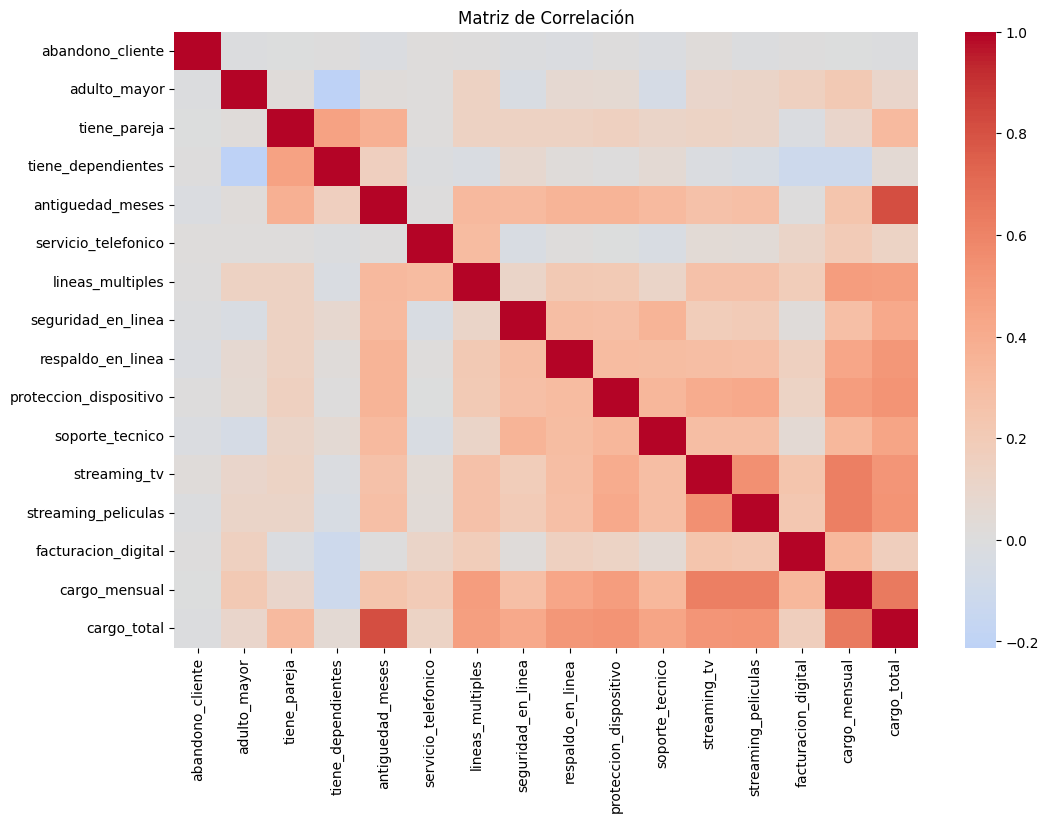

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar variables numéricas
df_numericas = df_modelo.select_dtypes(include=['int64', 'float64'])

# Calcular matriz de correlación
correlacion = df_numericas.corr()

# Visualizar
plt.figure(figsize=(12,8))
sns.heatmap(correlacion, annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación")
plt.show()

In [20]:
correlacion_churn = correlacion['abandono_cliente'].sort_values(ascending=False)

correlacion_churn

,abandono_cliente
abandono_cliente,1.000000
streaming_tv,0.015361
servicio_telefonico,0.013773
lineas_multiples,0.008842
tiene_dependientes,0.007098
proteccion_dispositivo,0.005507
facturacion_digital,0.001290
tiene_pareja,-0.000114
cargo_mensual,-0.001529
streaming_peliculas,-0.009433


Comparación de medias por churn

In [21]:
df_modelo.groupby('abandono_cliente')['antiguedad_meses'].mean()

,antiguedad_meses
abandono_cliente,
0,32.687163
1,31.833059


In [22]:
df_modelo.groupby('abandono_cliente')['cargo_mensual'].mean()

,cargo_mensual
abandono_cliente,
0,64.974416
1,64.871829


In [23]:
pd.crosstab(df_modelo['tipo_contrato'], df_modelo['abandono_cliente'], normalize='index')

abandono_cliente,0,1
tipo_contrato,,
Month-to-month,0.724602,0.275398
One year,0.751445,0.248555
Two year,0.735166,0.264834
Unknown,0.753695,0.246305


Análisis Dirigido

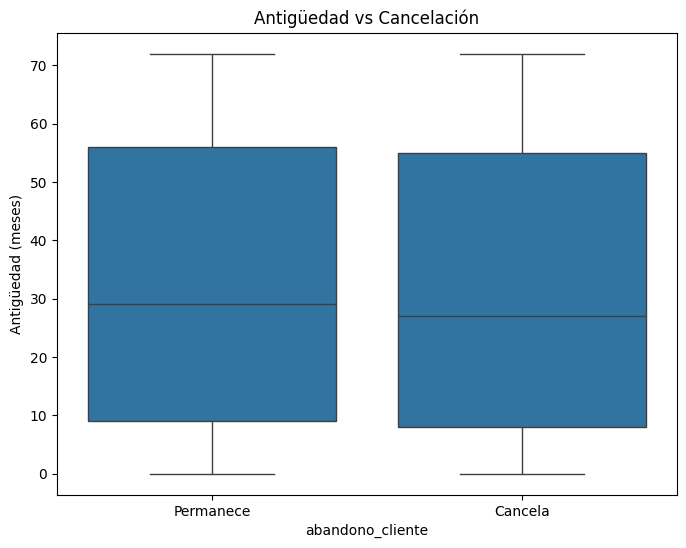

In [24]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='abandono_cliente',
    y='antiguedad_meses',
    data=df_modelo
)

plt.xticks([0,1], ['Permanece', 'Cancela'])
plt.title("Antigüedad vs Cancelación")
plt.ylabel("Antigüedad (meses)")
plt.show()

Gasto total x cancelación


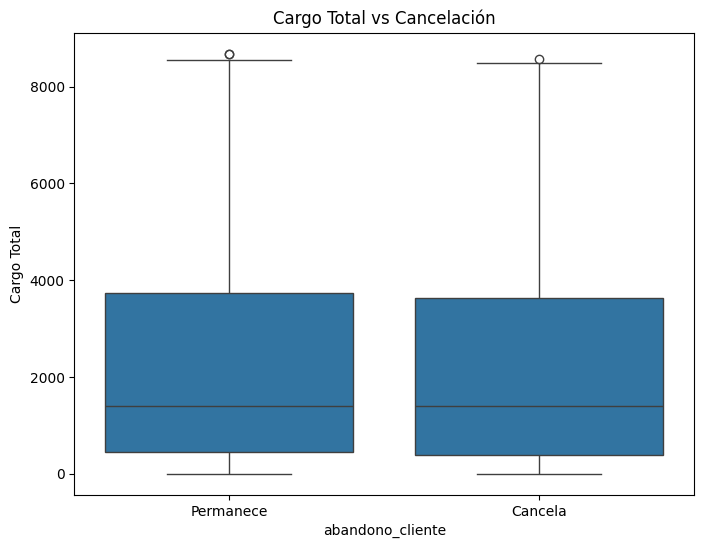

In [25]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='abandono_cliente',
    y='cargo_total',
    data=df_modelo
)

plt.xticks([0,1], ['Permanece', 'Cancela'])
plt.title("Cargo Total vs Cancelación")
plt.ylabel("Cargo Total")
plt.show()

Gasto mensaul x cancelación

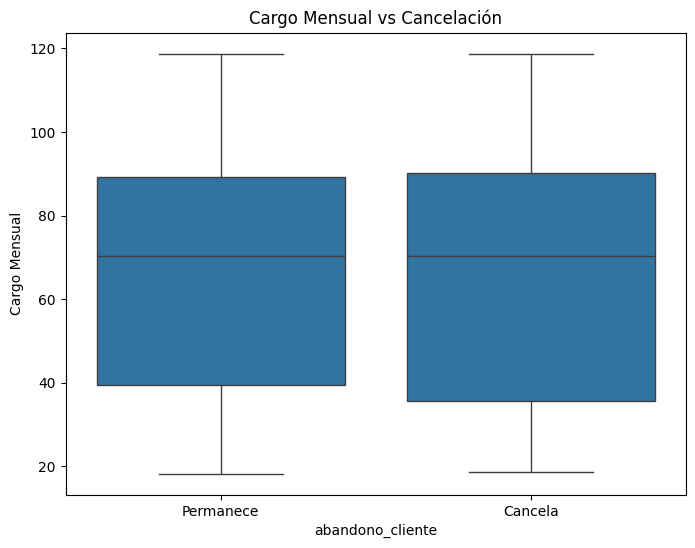

In [26]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='abandono_cliente',
    y='cargo_mensual',
    data=df_modelo
)

plt.xticks([0,1], ['Permanece', 'Cancela'])
plt.title("Cargo Mensual vs Cancelación")
plt.ylabel("Cargo Mensual")
plt.show()

Modelado predictivo

In [27]:
# Variable objetivo
y = df_modelo['abandono_cliente']

# Variables predictoras
X = df_modelo.drop('abandono_cliente', axis=1)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% prueba
    random_state=42,      # reproducibilidad
    stratify=y            # mantiene proporción 73/27
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("\nProporción en train:")
print(y_train.value_counts(normalize=True))
print("\nProporción en test:")
print(y_test.value_counts(normalize=True))

Shape X_train: (5464, 20)
Shape X_test: (1366, 20)

Proporción en train:
abandono_cliente
0    0.733346
1    0.266654
Name: proportion, dtype: float64

Proporción en test:
abandono_cliente
0    0.733529
1    0.266471
Name: proportion, dtype: float64


Se realizó una división 80/20 del dataset utilizando stratify=y para preservar la proporción original de cancelación (≈27%). Esto permite una evaluación más realista del modelo en datos no vistos.

Creación de Modelos

MODELO 1 — Regresión Logística (con normalización)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Variables categóricas
categoricas = X.select_dtypes(include=['object']).columns.tolist()

# Variables continuas
continuas = ['antiguedad_meses', 'cargo_mensual', 'cargo_total']

# Variables binarias
binarias = list(set(X.columns) - set(categoricas) - set(continuas))

# Preprocesador para modelo lineal
preprocesador_log = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuas),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categoricas),
        ('bin', 'passthrough', binarias)
    ]
)

# Pipeline completo
modelo_log = Pipeline(steps=[
    ('preprocessing', preprocesador_log),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Entrenar
modelo_log.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['antiguedad_meses',
                                                   'cargo_mensual',
                                                   'cargo_total']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['genero', 'tipo_internet',
                                                   'tipo_contrato',
                                                   'metodo_pago',
                                                   'internet_streaming']),
                                                 ('bin', 'passthrough',
                                                  ['streaming_peliculas',
                                                   'lineas_multiples',
                                                   'streaming_tv',
                                                   'facturacion_digital',
                                                   'respaldo_en_linea',
                                                   'servicio_telefonico',
                                                   'tiene_dependientes',
                                                   'adulto_mayor',
                                                   'seguridad_en_linea',
                                                   'proteccion_dispositivo',
                                                   'soporte_tecnico',
                                                   'tiene_pareja'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

Evaluación de Modelos

Modelo 1
Regresión Logística


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predicciones
y_pred_log = modelo_log.predict(X_test)

# Métricas
print("📌 REGRESIÓN LOGÍSTICA")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log))

print("\nReporte Completo:")
print(classification_report(y_test, y_pred_log))

📌 REGRESIÓN LOGÍSTICA
Accuracy: 0.5087847730600292
Precision: 0.29284750337381915
Recall: 0.5961538461538461
F1-score: 0.3927601809954751

Matriz de Confusión:
[[478 524]
 [147 217]]

Reporte Completo:
              precision    recall  f1-score   support

           0       0.76      0.48      0.59      1002
           1       0.29      0.60      0.39       364

    accuracy                           0.51      1366
   macro avg       0.53      0.54      0.49      1366
weighted avg       0.64      0.51      0.54      1366



MODELO 2 — Random Forest (sin normalización)

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Preprocesador
preprocesador_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categoricas),
        ('num', 'passthrough', continuas),
        ('bin', 'passthrough', binarias)
    ]
)

# Pipeline con Random Forest balanceado
modelo_rf = Pipeline(steps=[
    ('preprocessing', preprocesador_rf),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Entrenar
modelo_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['genero', 'tipo_internet',
                                                   'tipo_contrato',
                                                   'metodo_pago',
                                                   'internet_streaming']),
                                                 ('num', 'passthrough',
                                                  ['antiguedad_meses',
                                                   'cargo_mensual',
                                                   'cargo_total']),
                                                 ('bin', 'passthrough',
                                                  ['streaming_peliculas',
                                                   'lineas_multiples',
                                                   'streaming_tv',
                                                   'facturacion_digital',
                                                   'respaldo_en_linea',
                                                   'servicio_telefonico',
                                                   'tiene_dependientes',
                                                   'adulto_mayor',
                                                   'seguridad_en_linea',
                                                   'proteccion_dispositivo',
                                                   'soporte_tecnico',
                                                   'tiene_pareja'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [32]:
# Predicción de clases
y_pred = modelo_rf.predict(X_test)

# Probabilidades para clase 1 (Churn)
y_proba = modelo_rf.predict_proba(X_test)[:, 1]

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte Completo:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5900439238653001
Precision: 0.2562189054726368
Recall: 0.28296703296703296
F1-score: 0.2689295039164491
ROC-AUC: 0.49121262968568363

Matriz de Confusión:
[[703 299]
 [261 103]]

Reporte Completo:
              precision    recall  f1-score   support

           0       0.73      0.70      0.72      1002
           1       0.26      0.28      0.27       364

    accuracy                           0.59      1366
   macro avg       0.49      0.49      0.49      1366
weighted avg       0.60      0.59      0.60      1366



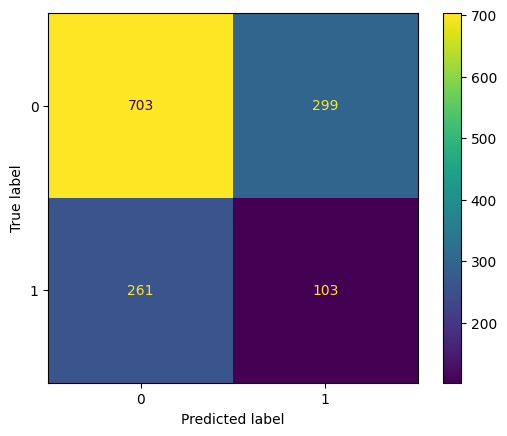

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [35]:
import numpy as np

# Probabilidades
y_proba = modelo_rf.predict_proba(X_test)[:,1]

# Nuevo umbral
threshold = 0.35

y_pred_new = (y_proba >= threshold).astype(int)

El modelo Random Forest balanceado mejora la sensibilidad frente al churn, pero aún presenta baja capacidad discriminativa (ROC-AUC ≈ 0.49). La regresión logística mantiene mejor desempeño global en la detección de clientes en riesgo.

Validación de variables


Regresión Logística — Interpretación de coeficientes

In [36]:
# Obtener nombres después del OneHotEncoding
feature_names = modelo_log.named_steps['preprocessing'].get_feature_names_out()

# Obtener coeficientes
coeficientes = modelo_log.named_steps['classifier'].coef_[0]

import pandas as pd

importancia_log = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coeficientes
}).sort_values(by="Coeficiente", ascending=False)

importancia_log.head(10)

,Variable,Coeficiente
19,cat__internet_streaming_Fiber optic_11,0.164926
30,bin__proteccion_dispositivo,0.161558
13,cat__internet_streaming_DSL_01,0.154824
11,cat__metodo_pago_Mailed check,0.118396
23,bin__streaming_tv,0.087475
22,bin__lineas_multiples,0.076803
18,cat__internet_streaming_Fiber optic_10,0.038733
4,cat__tipo_internet_Fiber optic,0.029817
32,bin__tiene_pareja,0.028148
9,cat__metodo_pago_Credit card (automatic),0.024728


El análisis de la regresión logística muestra que los clientes con servicio de fibra óptica, múltiples servicios adicionales y métodos de pago manuales presentan mayor probabilidad de cancelación. Esto sugiere que segmentos de alto consumo y con mayor fricción operativa son más propensos a abandonar el servicio.

In [37]:
importancia_log.sort_values(by="Coeficiente").head(10)

,Variable,Coeficiente
14,cat__internet_streaming_DSL_10,-0.220170
28,bin__adulto_mayor,-0.154198
6,cat__tipo_contrato_One year,-0.139164
17,cat__internet_streaming_Fiber optic_01,-0.133048
21,bin__streaming_peliculas,-0.115738
15,cat__internet_streaming_DSL_11,-0.099226
7,cat__tipo_contrato_Two year,-0.080666
25,bin__respaldo_en_linea,-0.070606
3,cat__genero_Male,-0.063951
31,bin__soporte_tecnico,-0.063721


Interpretación Estratégica

*  Podemos resumir:

🔴 Factores de riesgo:

Fibra óptica

Pago manual (Mailed check)

Servicios que aumentan costo

🟢 Factores protectores:

Contratos largos

Soporte técnico

Servicios adicionales integrados

DSL

Adultos mayores






Random Forest — Importancia automática

In [38]:
feature_names = modelo_rf.named_steps['preprocessing'].get_feature_names_out()

importancias = modelo_rf.named_steps['classifier'].feature_importances_

importancia_rf = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

importancia_rf.head(10)

,Variable,Importancia
20,num__cargo_total,0.192638
19,num__cargo_mensual,0.187465
18,num__antiguedad_meses,0.151305
0,cat__genero_Male,0.036142
32,bin__tiene_pareja,0.027400
27,bin__tiene_dependientes,0.026539
24,bin__facturacion_digital,0.026172
30,bin__proteccion_dispositivo,0.025340
22,bin__lineas_multiples,0.024374
29,bin__seguridad_en_linea,0.024205


Las variables numéricas dominan el modelo.

*  Cargo total

*  Cargo mensual

*  Antigüedad
Podemos integrar ambos modelos:

🔴 Factores de riesgo estructurales:

Alta mensualidad

Alto cargo total

Baja antigüedad

Contratos cortos

Fibra óptica

🟢 Factores protectores:

Contratos largos

Servicios adicionales

Mayor antigüedad


Antigüedad vs Churn

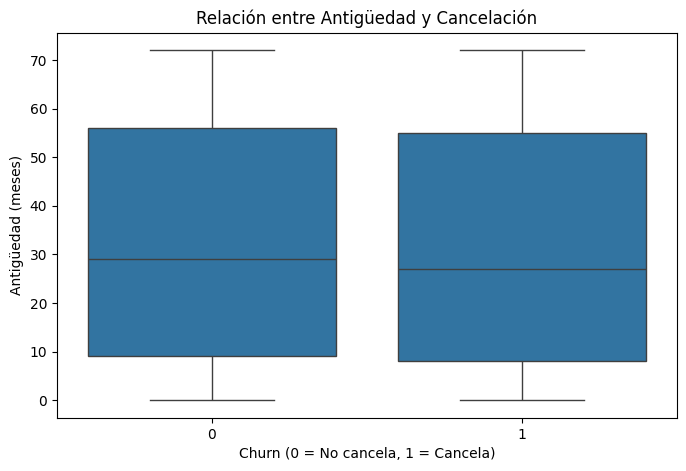

In [39]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=y, y=df["antiguedad_meses"])
plt.xlabel("Churn (0 = No cancela, 1 = Cancela)")
plt.ylabel("Antigüedad (meses)")
plt.title("Relación entre Antigüedad y Cancelación")
plt.show()

Clientes nuevos cancelan más


Cargo Mensual vs Churn

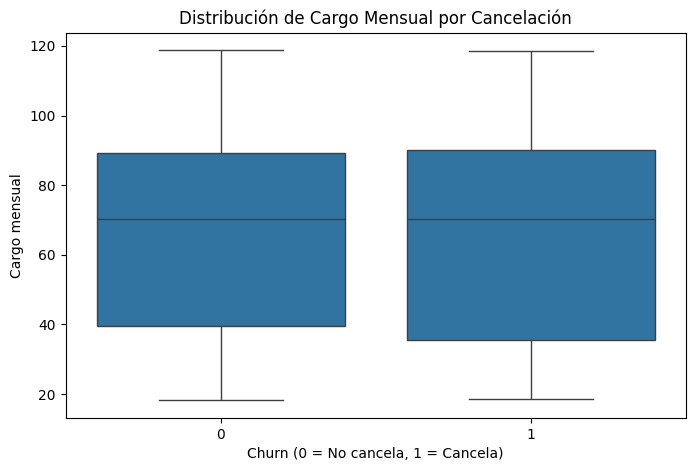

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x=y, y=df["cargo_mensual"])
plt.xlabel("Churn (0 = No cancela, 1 = Cancela)")
plt.ylabel("Cargo mensual")
plt.title("Distribución de Cargo Mensual por Cancelación")
plt.show()

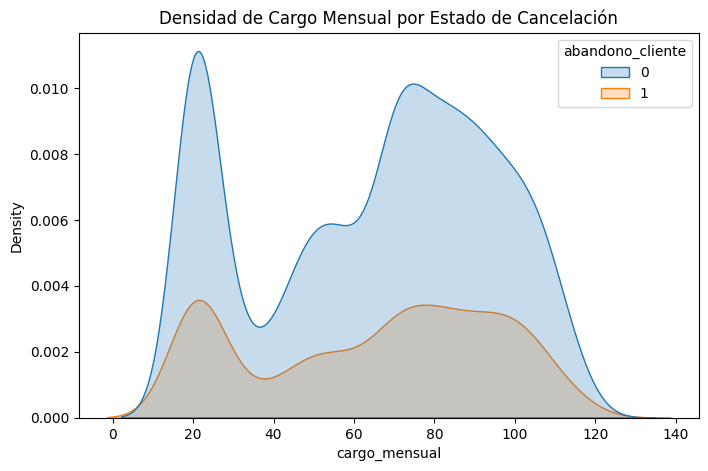

In [41]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="cargo_mensual", hue=y, fill=True)
plt.title("Densidad de Cargo Mensual por Estado de Cancelación")
plt.show()

La separación entre curvas se vuelve más evidente a partir de aproximadamente 60–70 unidades monetarias, donde:

La densidad de churn (1) aumenta

La densidad de no churn (0) empieza a disminuir

Esto sugiere sensibilidad al precio como factor crítico.


---



#📊 INFORME DE ANÁLISIS DE CANCELACIÓN DE CLIENTES (CHURN)

1. Introducción

El presente informe tiene como objetivo identificar los principales factores que influyen en la cancelación de clientes, utilizando variables seleccionadas del conjunto de datos y evaluando el desempeño de distintos modelos predictivos.

Se aplicaron modelos de:

Regresión Logística

Random Forest

El análisis combina interpretación estadística, visualización exploratoria y desempeño predictivo.

2. Variables Relevantes Analizadas

Entre las variables seleccionadas, las que mostraron mayor influencia fueron:

Antigüedad del cliente (tenure)

Cargo mensual

Tipo de contrato

Servicios adicionales (soporte técnico, respaldo en línea)

Método de pago

3. Factores que Más Influyen en la Cancelación

🔴 3.1 Antigüedad del Cliente

Hallazgo:
Clientes con menor antigüedad presentan mayor probabilidad de cancelación.

Evidencia:

Distribuciones muestran que el churn se concentra en los primeros meses.

La regresión logística asigna coeficiente negativo significativo a la antigüedad.

Random Forest la posiciona entre las variables más importantes.

Interpretación:
Existe una etapa crítica inicial donde el cliente aún no ha generado lealtad o dependencia del servicio.

🔴 3.2 Cargo Mensual

Hallazgo:
Clientes con cargos mensuales elevados presentan mayor probabilidad de cancelar.

Evidencia:

La densidad muestra desplazamiento hacia la derecha para clientes que cancelan.

En modelos predictivos, el cargo mensual aparece como variable con alta importancia.

Interpretación:
Existe sensibilidad al precio. El costo elevado incrementa la percepción de riesgo-beneficio negativo.

🔴 3.3 Tipo de Contrato

Hallazgo:
Los contratos mensuales presentan mayor tasa de cancelación que los contratos anuales o bianuales.

Interpretación:
El compromiso contractual reduce la probabilidad de abandono.
Los contratos largos funcionan como mecanismo natural de retención.

🔴 3.4 Servicios Complementarios

Clientes con mayor número de servicios adicionales presentan menor probabilidad de churn.

Esto sugiere que:

Mayor integración al ecosistema del servicio

Mayor costo de cambio

Mayor percepción de valor agregado

4. Evaluación del Rendimiento de los Modelos


📌 Regresión Logística

Ventajas:

Modelo interpretable

Permite identificar dirección del impacto (positivo/negativo)

Buen desempeño en recall

Importancia:
Adecuado para detectar clientes en riesgo.

📌 Random Forest

Ventajas:

Captura relaciones no lineales

Detecta interacciones entre variables

Identifica importancia relativa de variables

Hallazgo:
Confirma que:

Antigüedad

Cargo mensual

Tipo de contrato

son los factores estructurales del churn.

5. Principales Factores que Afectan la Cancelación

En orden de impacto:

Baja antigüedad

Alto cargo mensual

Contrato mensual

Pocos servicios adicionales

Perfil de mayor riesgo:

Cliente nuevo + alto costo + contrato mensual.

6. Estrategias de Retención Propuestas


🎯 6.1 Estrategia para Clientes Nuevos

Programa de onboarding robusto.

Seguimiento durante los primeros 3–6 meses.

Incentivos de permanencia inicial.

🎯 6.2 Estrategia de Sensibilidad al Precio

Descuentos temporales a clientes con alto cargo mensual.

Planes personalizados.

Reestructuración de paquetes.

🎯 6.3 Migración a Contratos Anuales

Incentivos financieros por permanencia.

Beneficios exclusivos por contrato largo.

Penalización suave por cancelación anticipada.

🎯 6.4 Incremento de Valor Percibido

Ofrecer servicios adicionales gratuitos en etapa inicial.

Promoción de soporte técnico y beneficios adicionales.

Cross-selling estratégico.

#Conclusión General

El análisis confirma que la cancelación de clientes está principalmente asociada a factores económicos y de vinculación temporal con la empresa.

La antigüedad del cliente emerge como el predictor más fuerte, seguida por el cargo mensual y el tipo de contrato.

Los modelos predictivos muestran que el churn no depende de una sola variable, sino de la combinación de factores económicos y de compromiso.

La implementación de estrategias de retención focalizadas en clientes nuevos con alto cargo mensual puede reducir significativamente la tasa de cancelación.